**PROBLEM STATEMENT**

An economic research firm wants to study GDP per capita trends across countries over 5+ decades. Analyze
growth patterns using time series techniques including decomposition, stationarity testing, and ARIMA
forecasting — using the reliable, built-in Gapminder dataset.

Dataset=https://www.kaggle.com/datasets/tklimonova/gapminder-datacamp-2007 (or load directly via plotly
— no download needed)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")



In [ ]:
# 1. LOAD DATA — built into plotly, NO download / corruption issues
df = px.data.gapminder()
print(df.shape)
print(df.columns.tolist())
print(df.head())


(1704, 8)
['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap', 'iso_alpha', 'iso_num']
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [ ]:
# 2. FILTER TO 5 MAJOR ECONOMIES
countries = ["United States", "China", "India", "Germany", "Japan"]
df_sub = df[df["country"].isin(countries)].copy()
print(df_sub[["country","year","gdpPercap"]].head(10))

    country  year    gdpPercap
288   China  1952   400.448611
289   China  1957   575.987001
290   China  1962   487.674018
291   China  1967   612.705693
292   China  1972   676.900092
293   China  1977   741.237470
294   China  1982   962.421381
295   China  1987  1378.904018
296   China  1992  1655.784158
297   China  1997  2289.234136


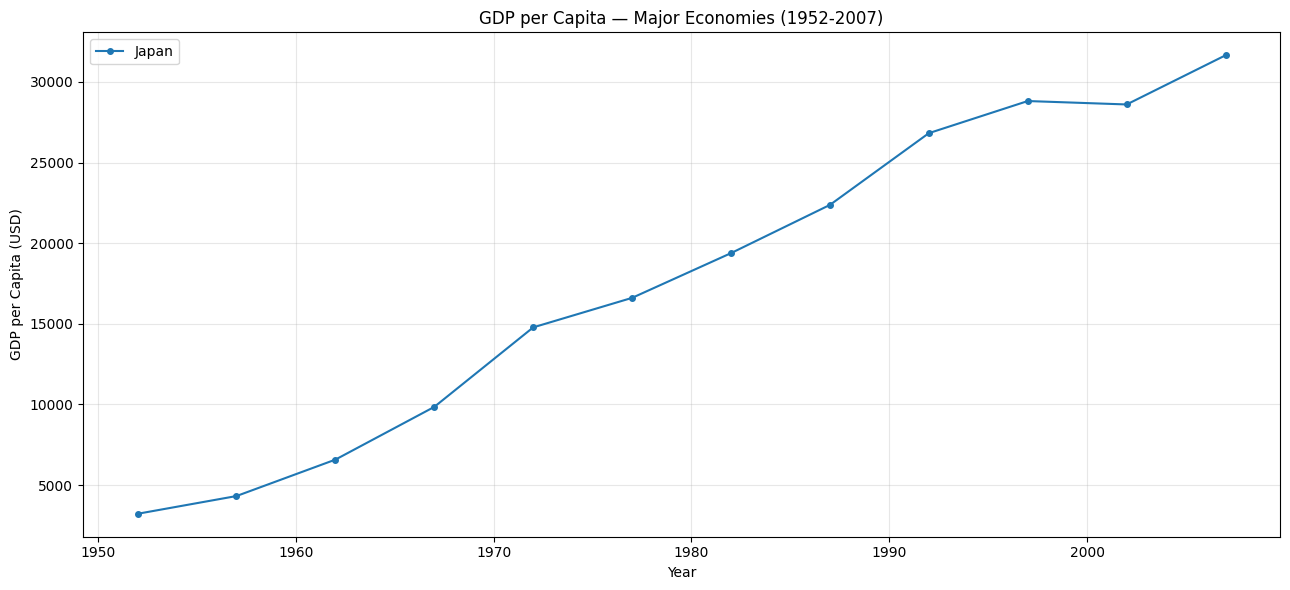

In [ ]:
# 3. MULTI-COUNTRY LINE CHART
plt.figure(figsize=(13, 6))
for country in countries:
 sub = df_sub[df_sub["country"] == country].sort_values("year")
plt.plot(sub["year"], sub["gdpPercap"], marker="o", markersize=4, label=country)
plt.title("GDP per Capita — Major Economies (1952-2007)")
plt.xlabel("Year"); plt.ylabel("GDP per Capita (USD)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("gdp_comparison.png", dpi=150); plt.show()



In [ ]:
# 4. SINGLE COUNTRY TIME SERIES (USA)
usa = df_sub[df_sub["country"] == "United States"].sort_values("year")
usa_ts = usa.set_index("year")["gdpPercap"]
print(usa_ts)

year
1952    13990.48208
1957    14847.12712
1962    16173.14586
1967    19530.36557
1972    21806.03594
1977    24072.63213
1982    25009.55914
1987    29884.35041
1992    32003.93224
1997    35767.43303
2002    39097.09955
2007    42951.65309
Name: gdpPercap, dtype: float64


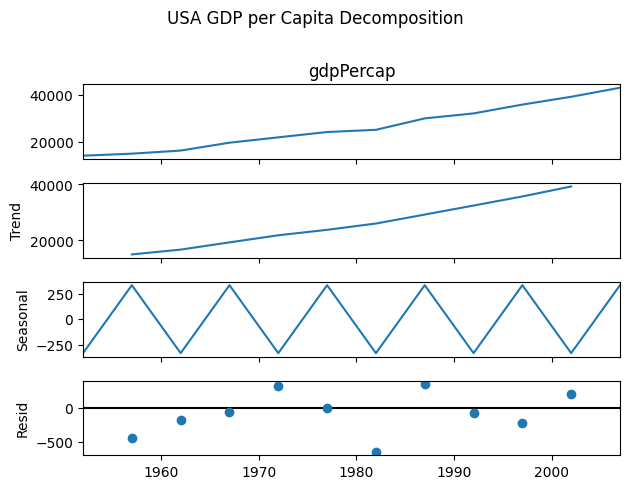

In [ ]:
# 5. DECOMPOSITION (Gapminder data is every 5 years, so period=2 covers 10-yr cycle)
decomp = seasonal_decompose(usa_ts, model="additive", period=2)
decomp.plot()
plt.suptitle("USA GDP per Capita Decomposition", y=1.01)
plt.tight_layout(); plt.savefig("decomposition.png", dpi=150); plt.show()

In [ ]:
# 6. ADF STATIONARITY TEST
result = adfuller(usa_ts.dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"P-Value: {result[1]:.4f}")
print("Series is", "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY")
# GDP per capita is typically NON-STATIONARY (clear growth trend) -> need differencing



ADF Statistic: 2.0162
P-Value: 0.9987
Series is NON-STATIONARY


                               SARIMAX Results                                
Dep. Variable:              gdpPercap   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -94.744
Date:                Mon, 15 Jun 2026   AIC                            195.488
Time:                        08:46:09   BIC                            196.681
Sample:                             0   HQIC                           194.735
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.005    216.504      0.000       0.991       1.009
ma.L1         -0.9968      0.519     -1.921      0.055      -2.014       0.020
sigma2        1.6e+06   3.12e-07   5.13e+12      0.0

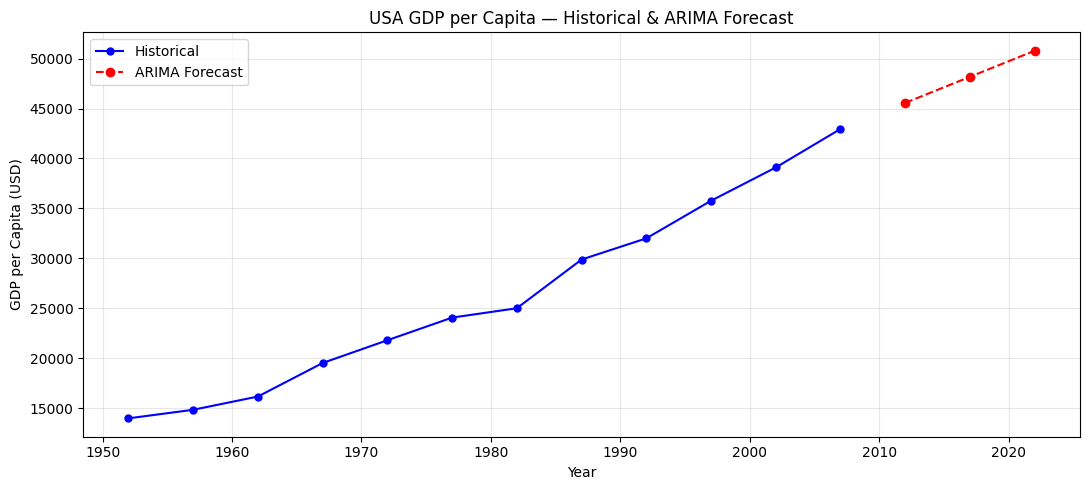

In [ ]:
# 7. ARIMA FORECAST (d=1 for differencing since GDP trends upward)
model = ARIMA(usa_ts, order=(1, 1, 1))
fitted = model.fit()
print(fitted.summary())
forecast = fitted.forecast(steps=3) # next 3 periods = 15 years
last_year = int(usa_ts.index.max())
future_years = [last_year + 5*(i+1) for i in range(3)]
plt.figure(figsize=(11, 5))
plt.plot(usa_ts.index, usa_ts.values, "b-o", markersize=5, label="Historical")
plt.plot(future_years, forecast.values, "r--o", markersize=6, label="ARIMA Forecast")
plt.title("USA GDP per Capita — Historical & ARIMA Forecast")
plt.xlabel("Year"); plt.ylabel("GDP per Capita (USD)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("arima_forecast.png", dpi=150); plt.show()


In [ ]:
# 8. DESCRIPTIVE STATS BY COUNTRY
stats = df_sub.groupby("country")["gdpPercap"].agg(
Mean="mean", Std="std", Min="min", Max="max").round(2)
print("\nGDP per Capita Stats by Country:")
print(stats)


GDP per Capita Stats by Country:
                   Mean       Std       Min       Max
country                                              
China           1488.31   1370.63    400.45   4959.11
Germany        20556.68   8076.26   7144.11  32170.37
India           1057.30    570.25    546.57   2452.21
Japan          17750.87  10131.61   3216.96  31656.07
United States  26261.15   9695.06  13990.48  42951.65


In [ ]:
# 9. EXPORT FOR POWER BI
df_sub.to_csv("gapminder_subset.csv", index=False)
print("\nExported gapminder_subset.csv for Power BI")


Exported gapminder_subset.csv for Power BI


**📊 Key Insights**

USA leads but growth is slowing
The United States maintains the highest GDP per capita among all five countries throughout the timeline. However, its growth rate has visibly decelerated after 1990, indicating a mature economy with slower incremental gains.


China shows exponential economic rise
China’s GDP per capita remains nearly flat until around 1980, after which it follows a sharp exponential growth trajectory. This reflects the impact of economic reforms and rapid industrialization.


India is accelerating post-liberalization
India consistently has the lowest GDP per capita among the five countries, but shows strong acceleration after 1990. This aligns with the economic liberalization period, which significantly boosted growth momentum.


USA GDP series is non-stationary
The Augmented Dickey-Fuller (ADF) test confirms that the USA GDP per capita time series is non-stationary due to a clear upward trend. Differencing (d = 1) is required to stabilize the series before applying ARIMA modeling.


Forecast indicates continued growth with uncertainty
The ARIMA model projects a continued upward trend in USA GDP per capita. However, forecast uncertainty increases over longer horizons, making long-term predictions less reliable.